# Metrics Comparison Histogram Analysis

This notebook loads the benchmark metrics comparison data and creates histograms to visualize the distribution of performance and RDF metrics across different generators.

## 1. Import Required Libraries

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Load CSV Data

In [32]:
# Load the metrics comparison CSV
df = pd.read_csv('metrics_comparison.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (160, 14)

Column Names:
['Generator', 'Run_ID', 'Perf_Throughput', 'Perf_Total_Triples', 'Perf_Execution_Time', 'RDF_Triples', 'RDF_Subjects', 'RDF_Predicates', 'RDF_Objects', 'RDF_Classes', 'RDF_Mean_Outdegree', 'RDF_Mean_Indegree', 'RDF_Coherence', 'RDF_Type_Coverage_Avg']

First few rows:


,Generator,Run_ID,Perf_Throughput,Perf_Total_Triples,Perf_Execution_Time,RDF_Triples,RDF_Subjects,RDF_Predicates,RDF_Objects,RDF_Classes,RDF_Mean_Outdegree,RDF_Mean_Indegree,RDF_Coherence,RDF_Type_Coverage_Avg
0,BSBM_HIGH_COHERENCE,run_1,1.025295e+06,35272182,34.40,35272182,3204145,40,5886014,2019,11.008298,5.992541,0.943216,0.81681
1,BSBM_HIGH_COHERENCE,run_10,1.028613e+06,35272182,34.29,35272182,3204145,40,5886014,2019,11.008298,5.992541,0.943216,0.81681
2,BSBM_HIGH_COHERENCE,run_2,9.678992e+05,35272182,36.44,35272182,3204145,40,5886014,2019,11.008298,5.992541,0.943216,0.81681
3,BSBM_HIGH_COHERENCE,run_3,1.003733e+06,35272182,35.14,35272182,3204145,40,5886014,2019,11.008298,5.992541,0.943216,0.81681
4,BSBM_HIGH_COHERENCE,run_4,1.028314e+06,35272182,34.30,35272182,3204145,40,5886014,2019,11.008298,5.992541,0.943216,0.81681


## 3. Data Preprocessing

In [33]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Extract coherence level (HIGH/LOW) from Generator name
df['Coherence_Level'] = df['Generator'].apply(lambda x: 'HIGH' if 'HIGH' in x else 'LOW')

# Extract base generator name (without coherence suffix)
df['Base_Generator'] = df['Generator'].apply(lambda x: x.replace('_HIGH_COHERENCE', '').replace('_LOW_COHERENCE', ''))

# Compute per-generator averages and standard deviations across the 10 runs
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df_avg = df.groupby(['Generator', 'Base_Generator', 'Coherence_Level'])[numeric_cols].mean().reset_index()
df_std = df.groupby(['Generator', 'Base_Generator', 'Coherence_Level'])[numeric_cols].std().reset_index()

print(f"\nRows before averaging: {len(df)}  →  after averaging: {len(df_avg)}")
print("\nAveraged Summary Statistics:")
df_avg.describe()

Missing Values:
Generator                0
Run_ID                   0
Perf_Throughput          0
Perf_Total_Triples       0
Perf_Execution_Time      0
RDF_Triples              0
RDF_Subjects             0
RDF_Predicates           0
RDF_Objects              0
RDF_Classes              0
RDF_Mean_Outdegree       0
RDF_Mean_Indegree        0
RDF_Coherence            0
RDF_Type_Coverage_Avg    0
dtype: int64

Rows before averaging: 160  →  after averaging: 16

Averaged Summary Statistics:


,Perf_Throughput,Perf_Total_Triples,Perf_Execution_Time,RDF_Triples,RDF_Subjects,RDF_Predicates,RDF_Objects,RDF_Classes,RDF_Mean_Outdegree,RDF_Mean_Indegree,RDF_Coherence,RDF_Type_Coverage_Avg
count,1.600000e+01,1.600000e+01,16.000000,1.600000e+01,1.600000e+01,16.000000,1.600000e+01,16.000000,16.000000,16.000000,16.000000,16.000000
mean,2.572670e+05,6.310958e+06,21.541187,6.558997e+06,1.137405e+06,24.118750,9.388701e+05,196.412500,19.309858,421.857242,0.747637,0.822915
std,3.462244e+05,9.819271e+06,6.988765,9.908760e+06,1.669725e+06,9.632945,1.579616e+06,517.637034,53.267083,1133.289354,0.265163,0.187512
min,1.643307e+03,9.655000e+03,6.832000,1.701020e+04,7.400000e+02,14.000000,4.900000e+01,15.000000,2.304140,2.151041,0.324188,0.452186
25%,1.869426e+04,4.131118e+05,18.513500,4.174905e+05,9.797440e+04,17.000000,4.927853e+04,15.000000,3.773585,5.898254,0.467658,0.747430
50%,3.706758e+04,7.501231e+05,22.934000,7.516231e+05,1.295840e+05,19.500000,1.532522e+05,23.000000,6.211670,8.481677,0.874329,0.880716
75%,5.032537e+05,1.031662e+07,25.607000,1.013795e+07,1.566583e+06,32.425000,1.227138e+06,50.300000,7.677353,11.876543,0.958470,0.978386
max,1.014980e+06,3.527218e+07,34.772000,3.527218e+07,4.730095e+06,40.000000,5.886014e+06,2019.000000,218.814865,3468.612245,0.998148,0.996667


## 4. Create Histograms for Performance Metrics

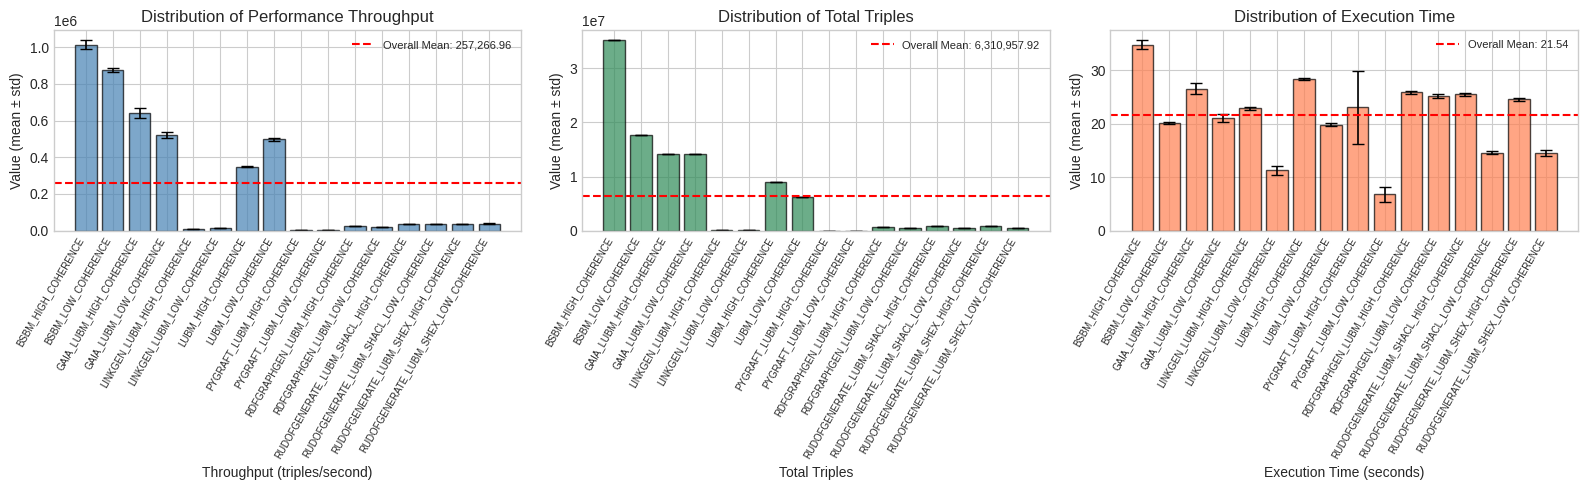

In [34]:
# Create histograms for Performance Metrics (averaged across 10 runs, with std whiskers)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

perf_metrics = ['Perf_Throughput', 'Perf_Total_Triples', 'Perf_Execution_Time']
perf_labels  = ['Throughput (triples/second)', 'Total Triples', 'Execution Time (seconds)']
perf_colors  = ['steelblue', 'seagreen', 'coral']
perf_titles  = ['Distribution of Performance Throughput',
                'Distribution of Total Triples',
                'Distribution of Execution Time']

for i, (col, label, color, title) in enumerate(zip(perf_metrics, perf_labels, perf_colors, perf_titles)):
    means = df_avg[col].values
    stds  = df_std[col].values
    gen_labels = df_avg['Generator'].values
    x_pos = np.arange(len(means))

    axes[i].bar(x_pos, means, yerr=stds, capsize=4, edgecolor='black',
                alpha=0.7, color=color, error_kw={'linewidth': 1.2})
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Value (mean ± std)')
    axes[i].set_title(title)
    axes[i].set_xticks(x_pos)
    axes[i].set_xticklabels(gen_labels, rotation=60, ha='right', fontsize=7)
    overall_mean = df_avg[col].mean()
    axes[i].axhline(overall_mean, color='red', linestyle='--',
                    label=f'Overall Mean: {overall_mean:,.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Create Histograms for RDF Metrics

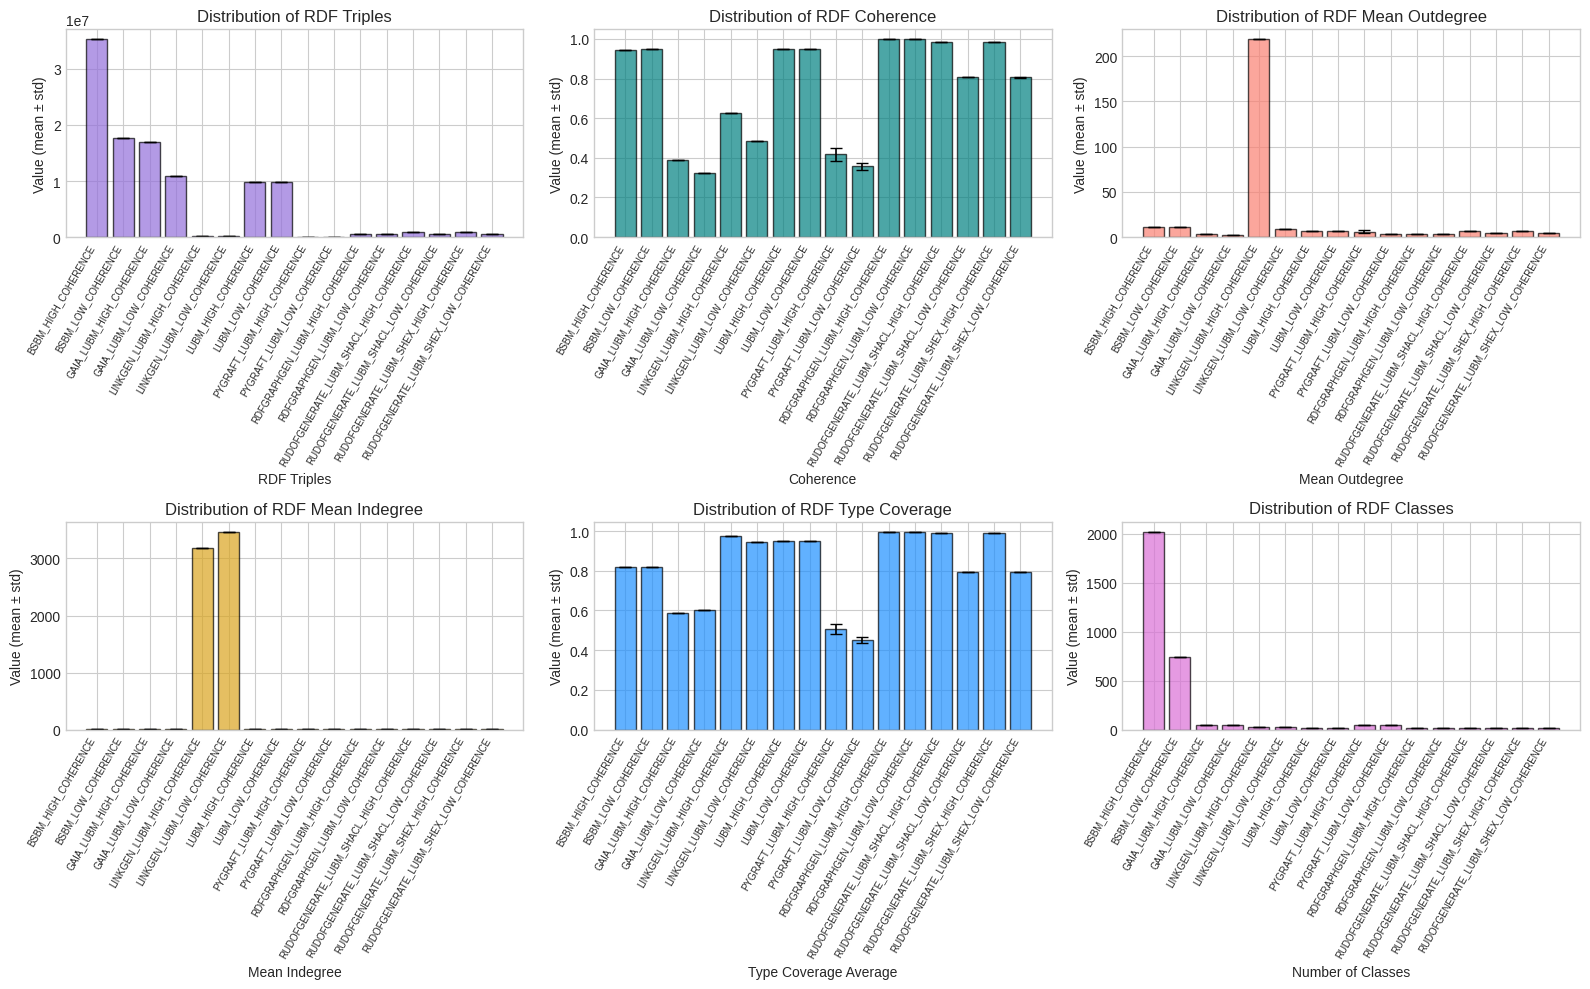

In [35]:
# Create histograms for RDF Metrics (averaged across 10 runs, with std whiskers)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

rdf_metrics = ['RDF_Triples', 'RDF_Coherence', 'RDF_Mean_Outdegree',
               'RDF_Mean_Indegree', 'RDF_Type_Coverage_Avg', 'RDF_Classes']
rdf_labels  = ['RDF Triples', 'Coherence', 'Mean Outdegree',
               'Mean Indegree', 'Type Coverage Average', 'Number of Classes']
rdf_colors  = ['mediumpurple', 'teal', 'salmon',
               'goldenrod', 'dodgerblue', 'orchid']
rdf_titles  = ['Distribution of RDF Triples', 'Distribution of RDF Coherence',
               'Distribution of RDF Mean Outdegree', 'Distribution of RDF Mean Indegree',
               'Distribution of RDF Type Coverage', 'Distribution of RDF Classes']

gen_labels = df_avg['Generator'].values
x_pos = np.arange(len(gen_labels))

for idx, (col, label, color, title) in enumerate(zip(rdf_metrics, rdf_labels, rdf_colors, rdf_titles)):
    row, c = divmod(idx, 3)
    means = df_avg[col].values
    stds  = df_std[col].values

    axes[row, c].bar(x_pos, means, yerr=stds, capsize=4, edgecolor='black',
                     alpha=0.7, color=color, error_kw={'linewidth': 1.2})
    axes[row, c].set_xlabel(label)
    axes[row, c].set_ylabel('Value (mean ± std)')
    axes[row, c].set_title(title)
    axes[row, c].set_xticks(x_pos)
    axes[row, c].set_xticklabels(gen_labels, rotation=60, ha='right', fontsize=7)

plt.tight_layout()
plt.show()

## 6. Create Grouped Histograms by Generator

In [36]:

# Shared settings for all grouped bar charts
TITLE_SIZE = 12
LABEL_SIZE = 10
TICK_SIZE = 9
LEGEND_SIZE = 9
FIG_W = 7
FIG_H = 5

colors = {'HIGH': 'steelblue', 'LOW': 'coral'}
generators = df_avg['Base_Generator'].unique()
x = np.arange(len(generators))
width = 0.35

# Pre-build HIGH / LOW mean and std lookup by Base_Generator
avg_high = df_avg[df_avg['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')
avg_low  = df_avg[df_avg['Coherence_Level'] == 'LOW'].set_index('Base_Generator')
std_high = df_std[df_std['Coherence_Level'] == 'HIGH'].set_index('Base_Generator')
std_low  = df_std[df_std['Coherence_Level'] == 'LOW'].set_index('Base_Generator')


### 6.1 Throughput by Generator (Broken Y-Axis)

Saved: output_charts/throughput_by_generator.pdf


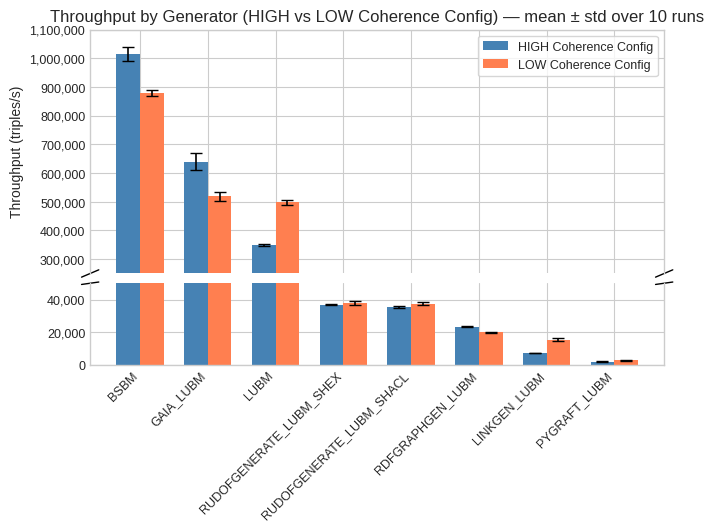

In [37]:

# Throughput by Generator — Broken Y-Axis (mean of 10 runs ± std)
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(FIG_W, FIG_H),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.06}
)

# Sort generators by HIGH throughput descending
sorted_gens_tp = sorted(generators, key=lambda g: avg_high['Perf_Throughput'].get(g, 0), reverse=True)
x_tp = np.arange(len(sorted_gens_tp))
high_vals = [avg_high['Perf_Throughput'].get(g, 0) for g in sorted_gens_tp]
low_vals  = [avg_low['Perf_Throughput'].get(g, 0)  for g in sorted_gens_tp]
high_err  = [std_high['Perf_Throughput'].get(g, 0) for g in sorted_gens_tp]
low_err   = [std_low['Perf_Throughput'].get(g, 0)  for g in sorted_gens_tp]

err_kw = {'linewidth': 1.2}
ax_top.bar(x_tp - width/2, high_vals, width, yerr=high_err, capsize=4,
           label='HIGH Coherence Config', color=colors['HIGH'], error_kw=err_kw)
ax_top.bar(x_tp + width/2, low_vals, width, yerr=low_err, capsize=4,
           label='LOW Coherence Config', color=colors['LOW'], error_kw=err_kw)
ax_bot.bar(x_tp - width/2, high_vals, width, yerr=high_err, capsize=4,
           color=colors['HIGH'], error_kw=err_kw)
ax_bot.bar(x_tp + width/2, low_vals, width, yerr=low_err, capsize=4,
           color=colors['LOW'], error_kw=err_kw)

ax_top.set_ylim(250_000, 1_100_000)
ax_bot.set_ylim(0, 50_000)

ax_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax_bot.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.tick_params(axis='x', bottom=False)
plt.setp(ax_top.get_xticklabels(), visible=False)

# Diagonal break marks
d = 0.015
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bot.set_xticks(x_tp)
ax_bot.set_xticklabels(sorted_gens_tp, rotation=45, ha='right', fontsize=TICK_SIZE)
ax_top.tick_params(axis='y', labelsize=TICK_SIZE)
ax_bot.tick_params(axis='y', labelsize=TICK_SIZE)
ax_top.set_ylabel('Throughput (triples/s)', fontsize=LABEL_SIZE)
ax_top.set_title('Throughput by Generator (HIGH vs LOW Coherence Config) — mean ± std over 10 runs', fontsize=TITLE_SIZE)
ax_top.legend(fontsize=LEGEND_SIZE, loc='upper right', frameon=True)

fig.subplots_adjust(left=0.14, right=0.96, bottom=0.25, top=0.92)
fig.savefig('output_charts/throughput_by_generator.pdf', format='pdf', bbox_inches='tight')
print('Saved: output_charts/throughput_by_generator.pdf')

plt.show()


### 6.2 RDF Coherence by Generator

Saved: output_charts/coherence_by_generator.pdf


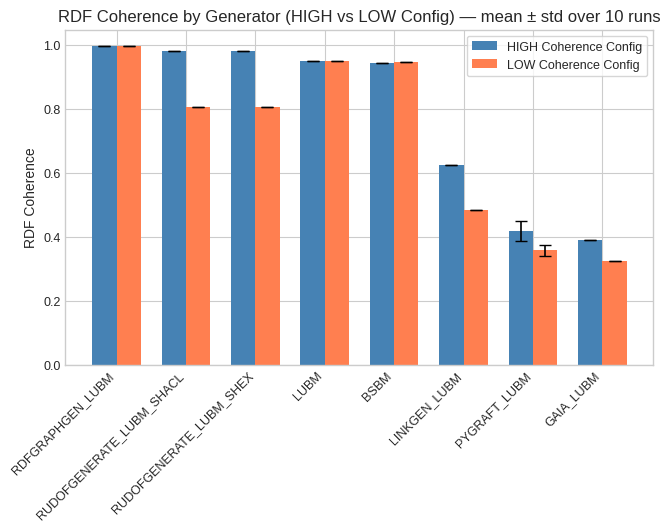

In [38]:

# RDF Coherence by Generator (mean of 10 runs ± std)
fig, ax_coh = plt.subplots(figsize=(FIG_W, FIG_H))

# Sort generators by HIGH coherence descending
sorted_gens = sorted(generators, key=lambda g: avg_high['RDF_Coherence'].get(g, 0), reverse=True)
x_coh = np.arange(len(sorted_gens))

high_vals = [avg_high['RDF_Coherence'].get(g, 0) for g in sorted_gens]
low_vals  = [avg_low['RDF_Coherence'].get(g, 0)  for g in sorted_gens]
high_err  = [std_high['RDF_Coherence'].get(g, 0) for g in sorted_gens]
low_err   = [std_low['RDF_Coherence'].get(g, 0)  for g in sorted_gens]

err_kw = {'linewidth': 1.2}
ax_coh.bar(x_coh - width/2, high_vals, width, yerr=high_err, capsize=4,
           label='HIGH Coherence Config', color=colors['HIGH'], error_kw=err_kw)
ax_coh.bar(x_coh + width/2, low_vals, width, yerr=low_err, capsize=4,
           label='LOW Coherence Config', color=colors['LOW'], error_kw=err_kw)
ax_coh.set_ylabel('RDF Coherence', fontsize=LABEL_SIZE)
ax_coh.set_title('RDF Coherence by Generator (HIGH vs LOW Config) — mean ± std over 10 runs', fontsize=TITLE_SIZE)
ax_coh.set_xticks(x_coh)
ax_coh.set_xticklabels(sorted_gens, rotation=45, ha='right', fontsize=TICK_SIZE)
ax_coh.tick_params(axis='y', labelsize=TICK_SIZE)
ax_coh.legend(fontsize=LEGEND_SIZE, loc='upper right', frameon=True)

fig.subplots_adjust(left=0.12, right=0.96, bottom=0.25, top=0.92)
fig.savefig('output_charts/coherence_by_generator.pdf', format='pdf', bbox_inches='tight')
print('Saved: output_charts/coherence_by_generator.pdf')

plt.show()


### 6.3 Execution Time by Generator

Saved: output_charts/execution_time_by_generator.pdf


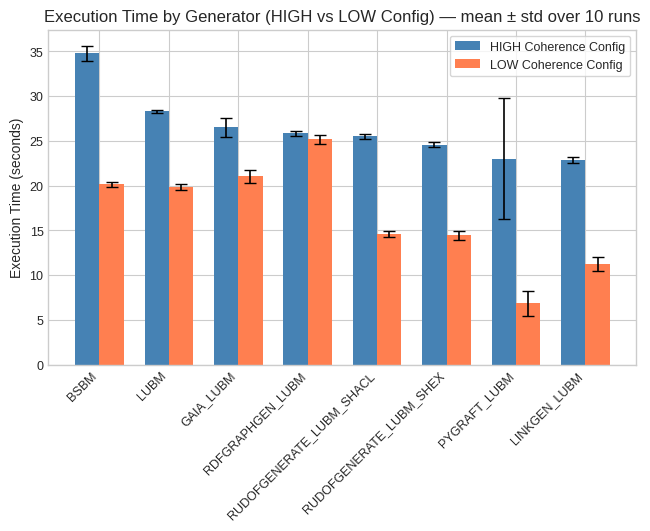

In [39]:

# Execution Time by Generator (mean of 10 runs ± std)
fig, ax_time = plt.subplots(figsize=(FIG_W, FIG_H))

# Sort generators by HIGH execution time descending
sorted_gens_et = sorted(generators, key=lambda g: avg_high['Perf_Execution_Time'].get(g, 0), reverse=True)
x_et = np.arange(len(sorted_gens_et))

high_vals = [avg_high['Perf_Execution_Time'].get(g, 0) for g in sorted_gens_et]
low_vals  = [avg_low['Perf_Execution_Time'].get(g, 0)  for g in sorted_gens_et]
high_err  = [std_high['Perf_Execution_Time'].get(g, 0) for g in sorted_gens_et]
low_err   = [std_low['Perf_Execution_Time'].get(g, 0)  for g in sorted_gens_et]

err_kw = {'linewidth': 1.2}
ax_time.bar(x_et - width/2, high_vals, width, yerr=high_err, capsize=4,
            label='HIGH Coherence Config', color=colors['HIGH'], error_kw=err_kw)
ax_time.bar(x_et + width/2, low_vals, width, yerr=low_err, capsize=4,
            label='LOW Coherence Config', color=colors['LOW'], error_kw=err_kw)
ax_time.set_ylabel('Execution Time (seconds)', fontsize=LABEL_SIZE)
ax_time.set_title('Execution Time by Generator (HIGH vs LOW Config) — mean ± std over 10 runs', fontsize=TITLE_SIZE)
ax_time.set_xticks(x_et)
ax_time.set_xticklabels(sorted_gens_et, rotation=45, ha='right', fontsize=TICK_SIZE)
ax_time.tick_params(axis='y', labelsize=TICK_SIZE)
ax_time.legend(fontsize=LEGEND_SIZE, loc='upper right', frameon=True)

fig.subplots_adjust(left=0.12, right=0.96, bottom=0.25, top=0.92)
fig.savefig('output_charts/execution_time_by_generator.pdf', format='pdf', bbox_inches='tight')
print('Saved: output_charts/execution_time_by_generator.pdf')

plt.show()


In [40]:
# Inspect PYGRAFT variability across the 10 runs
pyg = df[df['Base_Generator'] == 'PYGRAFT_LUBM']
for lvl in ['HIGH', 'LOW']:
    sub = pyg[pyg['Coherence_Level'] == lvl]
    print(f"\n=== PYGRAFT {lvl} COHERENCE ===")
    for col in ['Perf_Execution_Time', 'Perf_Throughput', 'Perf_Total_Triples',
                'RDF_Triples', 'RDF_Subjects', 'RDF_Predicates', 'RDF_Classes', 'RDF_Coherence']:
        vals = sub[col]
        print(f"  {col:30s}  mean={vals.mean():12.2f}  std={vals.std():12.2f}  "
              f"min={vals.min():12.2f}  max={vals.max():12.2f}  CV={vals.std()/vals.mean()*100:.1f}%")


=== PYGRAFT HIGH COHERENCE ===
  Perf_Execution_Time             mean=       23.02  std=        6.77  min=        4.33  max=       27.86  CV=29.4%
  Perf_Throughput                 mean=     1643.31  std=      362.27  min=     1373.80  max=     2634.41  CV=22.0%
  Perf_Total_Triples              mean=    11723.60  std=      911.95  min=     9164.00  max=    12172.00  CV=7.8%
  RDF_Triples                     mean=    35622.80  std=     8508.90  min=    11407.00  max=    38395.00  CV=23.9%
  RDF_Subjects                    mean=     5785.80  std=      455.98  min=     4506.00  max=     6010.00  CV=7.9%
  RDF_Predicates                  mean=       34.20  std=        3.22  min=       29.00  max=       39.00  CV=9.4%
  RDF_Classes                     mean=       51.40  std=        0.70  min=       50.00  max=       52.00  CV=1.4%
  RDF_Coherence                   mean=        0.42  std=        0.03  min=        0.34  max=        0.44  CV=7.7%

=== PYGRAFT LOW COHERENCE ===
  Perf_Executi